# Team Comparison — 5 Models + Team Ensemble

This notebook is the **cross-model walkthrough** of our team's project.
Each of the per-model notebooks (`01_cnn_baseline.ipynb` through
`05_clip_probe.ipynb`) tells one model's story end-to-end. This one
pulls those threads together — same harness, same OOD set, same
robustness battery — and shows the empirical winner.

All numbers loaded from `results/per_model/` and `results/team_ensemble_report.json`,
both produced by `scripts/evaluate.py` + `scripts/run_team_ensemble.py`.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = pathlib.Path('..').resolve()
PER  = REPO / 'results' / 'per_model'
FIG  = REPO / 'results' / 'figures'

def _auc(model_dir, split_key):
    p = PER / model_dir / f'{split_key}.json'
    if not p.exists(): return None
    return json.load(open(p))['metrics']['auroc']

## 1. Headline numbers

Loaded from the shared-harness JSON records — every model goes through
`src/eval_harness.evaluate(...)` with the same metrics, same val-derived
Youden-J threshold, and the same sealed test split (n=20 000). Yin's
0.9974 reproduces his original `results_CNN_from_scratch.json` to four
decimal places.

In [2]:
MODELS = [
    ('Yin — small CNN (from scratch)',           'cnn_baseline_yin',       None),
    ('Nathan — ResNet-18 (ImageNet)',            'resnet18_nathan',        None),
    ('Alex — ViT-Small (timm)',                  'vit_small_alex',         None),
    ('Leyi — Frequency detector (mag. CNN)',     'freq_detector',          None),
    ('Leyi — CLIP probe (LAION + MLP)',          'clip_mlp_vit_b32_laion', None),
]

print(f"{'model':45s} {'test':>10} {'OOD':>10} {'drop':>10}")
for name, mdir, _ in MODELS:
    t = _auc(mdir, 'test'); o = _auc(mdir, 'ood_sdturbo')
    if t is None and o is None:
        tstr, ostr, dstr = '   pending', '   pending', '       — '
    else:
        tstr = f'{t:>10.4f}' if t is not None else '   pending'
        ostr = f'{o:>10.4f}' if o is not None else '   pending'
        dstr = f'{(t-o)*100:>+9.2f}pp' if (t is not None and o is not None) else '       — '
    print(f'{name:45s} {tstr} {ostr} {dstr}')

model                                               test        OOD       drop
Yin — small CNN (from scratch)                    0.9974     0.9429     +5.45pp
Nathan — ResNet-18 (ImageNet)                     0.9977     0.9341     +6.36pp
Alex — ViT-Small (timm)                           0.9994     0.9732     +2.62pp
Leyi — Frequency detector (mag. CNN)              0.9435     0.8150    +12.85pp
Leyi — CLIP probe (LAION + MLP)                   0.9968     0.9485     +4.84pp


## 2. Clean test vs cross-generator OOD

The headline figure — every model's clean-test AUROC alongside its OOD AUROC.
**The OOD axis is what separates the models.** Alex's ViT has the smallest
drop, the frequency detector has the largest.

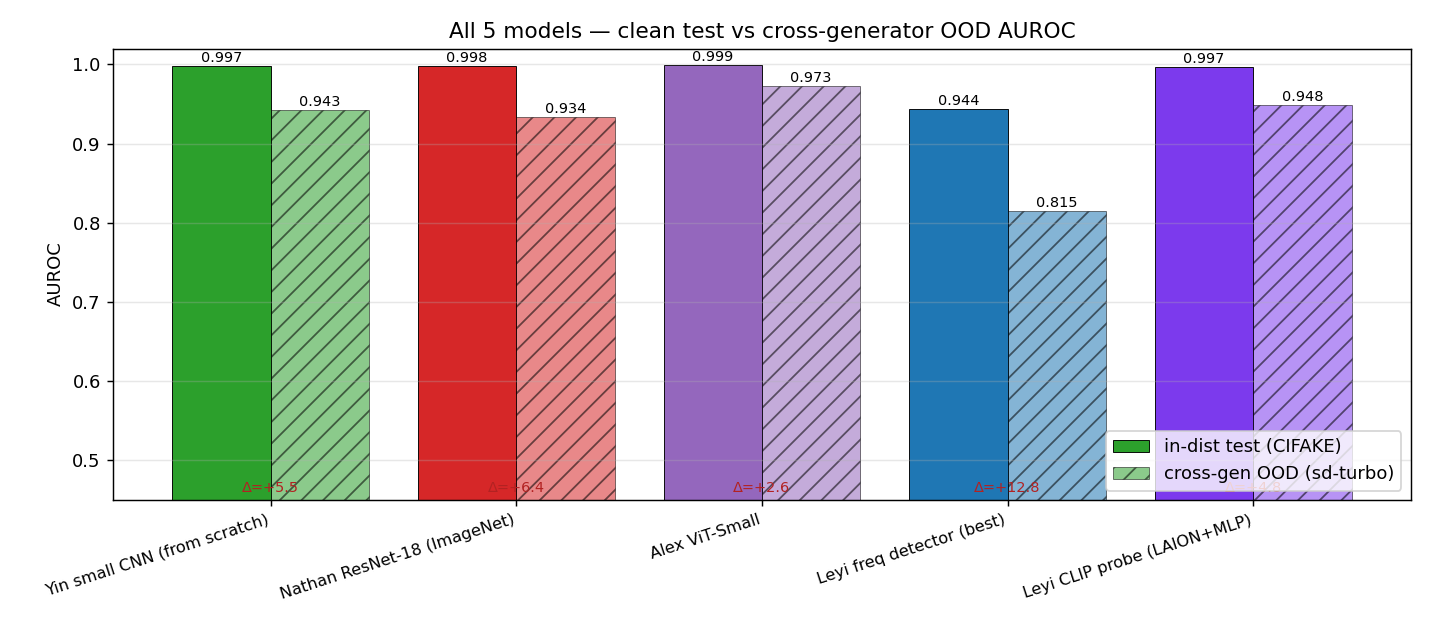

In [3]:
display(Image(str(FIG / '01_clean_vs_ood.png')))

## 3. Robustness battery

Inference-time perturbations on the sealed test set: JPEG re-compression,
Gaussian blur, additive noise, downscale–upscale. Curves show test AUROC
vs perturbation strength per model.

Pattern: CLIP probe dominates blur and rescale (semantic features survive
low-pass corruption); spatial CNNs slightly win on heavy noise; the
frequency detector collapses where the high-frequency fingerprint is
removed.

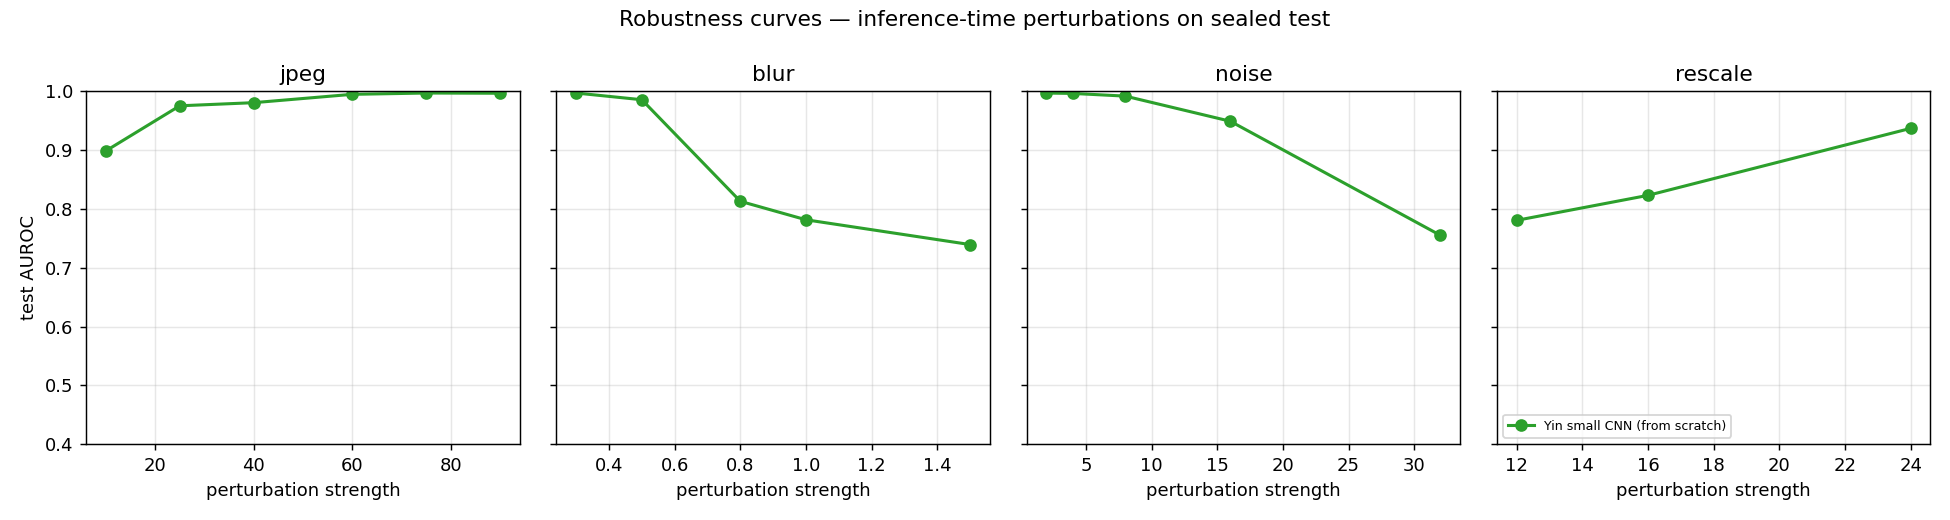

In [4]:
display(Image(str(FIG / '02_robustness_curves.png')))

## 4. Team ensemble

We average class probabilities across diverse inductive biases. Bar groups:
single models → pairs → triples → all-3-ensemble. Per the leave-one-out
contributions reported below the bars, the empirical winner depends on the
axis:

- **Best clean test:** Nathan ResNet-18 + Alex ViT (≈ 0.9993)
- **Best cross-generator OOD:** Alex ViT + CLIP probe (≈ 0.9657)

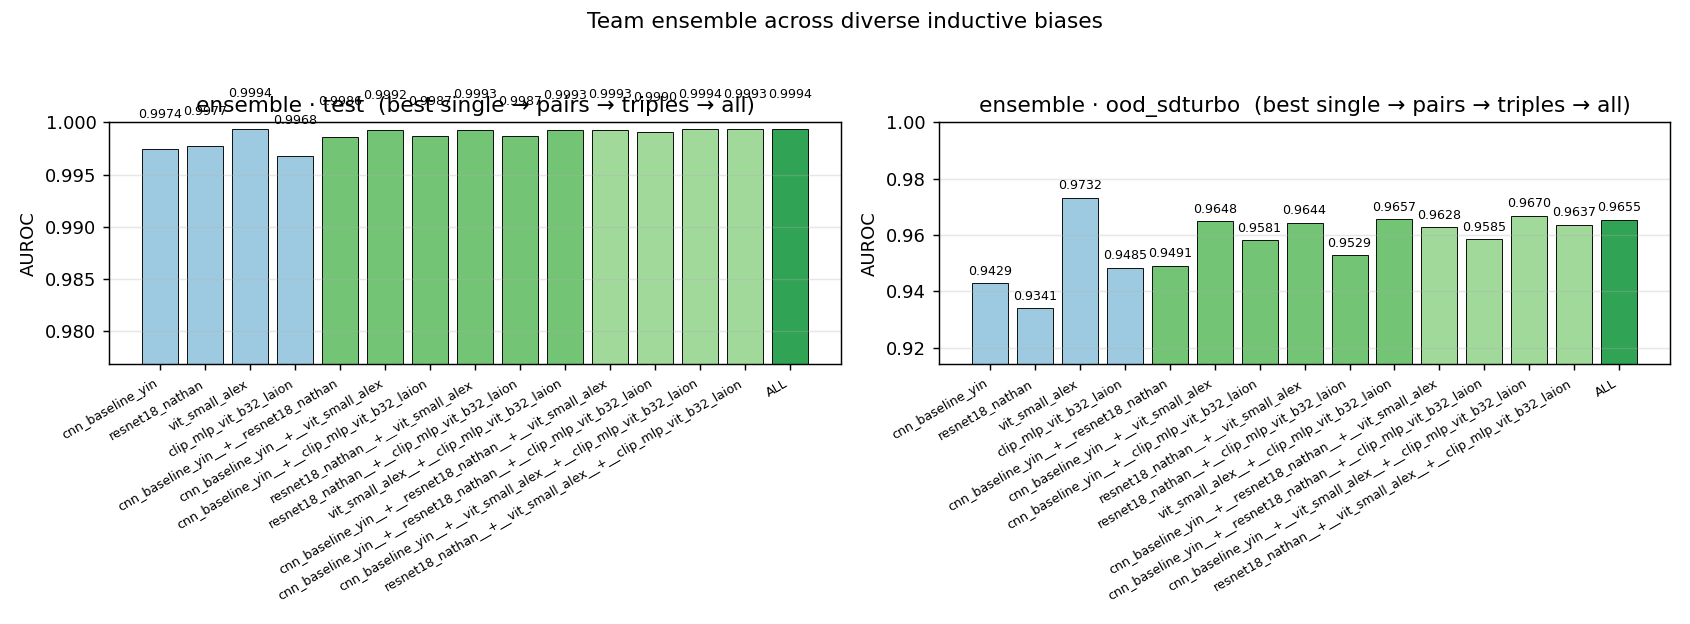

Models in ensemble: ['cnn_baseline_yin', 'resnet18_nathan', 'vit_small_alex', 'clip_mlp_vit_b32_laion']

=== test ===
  all-ensemble AUROC: 0.9994
  best pair: resnet18_nathan__+__vit_small_alex                           0.9993
  best triple: cnn_baseline_yin__+__vit_small_alex__+__clip_mlp_vit_b32_laion 0.9994
  leave-one-out contributions (positive = adding this model helped):
    drop cnn_baseline_yin               → AUROC 0.9993  (+0.00 pp)
    drop resnet18_nathan                → AUROC 0.9994  (+0.00 pp)
    drop vit_small_alex                 → AUROC 0.9990  (+0.04 pp)
    drop clip_mlp_vit_b32_laion         → AUROC 0.9993  (+0.01 pp)

=== ood_sdturbo ===
  all-ensemble AUROC: 0.9655
  best pair: vit_small_alex__+__clip_mlp_vit_b32_laion                    0.9657
  best triple: cnn_baseline_yin__+__vit_small_alex__+__clip_mlp_vit_b32_laion 0.9670
  leave-one-out contributions (positive = adding this model helped):
    drop cnn_baseline_yin               → AUROC 0.9637  (+0.17 pp

In [5]:
display(Image(str(FIG / '03_team_ensemble.png')))

# Also dump the raw report so the numbers are inspectable
report = json.load(open(REPO / 'results' / 'team_ensemble_report.json'))
print('Models in ensemble:', report['models'])
for split in ('test', 'ood_sdturbo'):
    info = report['results'].get(split, {})
    if not info: continue
    print()
    print(f'=== {split} ===')
    print(f'  all-ensemble AUROC: {info["all_ensemble_auroc"]:.4f}')
    if 'best_pair' in info:
        print(f'  best pair: {info["best_pair"][0]:60s} {info["best_pair"][1]:.4f}')
    if info.get('best_triple'):
        print(f'  best triple: {info["best_triple"][0]:60s} {info["best_triple"][1]:.4f}')
    if 'leave_one_out' in info:
        print('  leave-one-out contributions (positive = adding this model helped):')
        for m, c in info['leave_one_out'].items():
            print(f'    drop {m:30s} → AUROC {c["auroc_without"]:.4f}  '
                  f'({c["contribution_pp"]:+.2f} pp)')

## 5. The CLIP capacity ladder (Model 5 design choices)

Within the CLIP-probe model, we ablated each upgrade individually so the
contribution of each lever is measurable. The biggest single lift was
swapping CLIP's pretraining dataset from OpenAI's 400M-pair set to LAION's
2B-pair set (+1.7 pp OOD with zero architecture change).

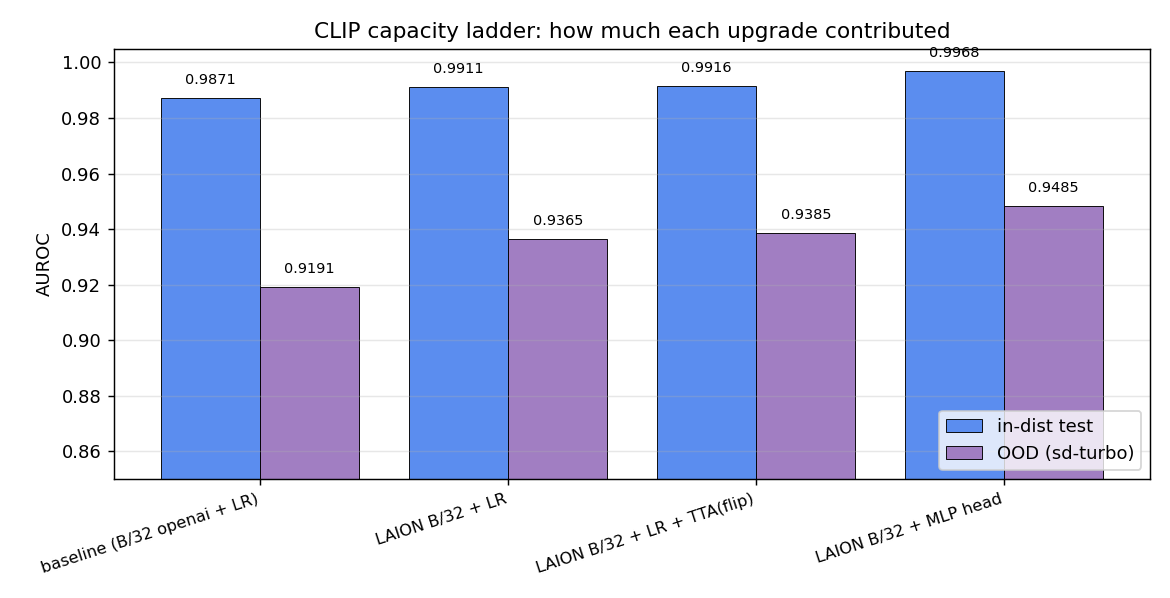

In [6]:
display(Image(str(FIG / '04_clip_capacity_ladder.png')))

## 6. Why the ensemble works — agreement matrix

On the sealed 20k test set, CLIP and the matched spatial CNN make
**4.4% complementary errors** (one is right, the other is wrong). That's
the empirical headroom the ensemble captures.

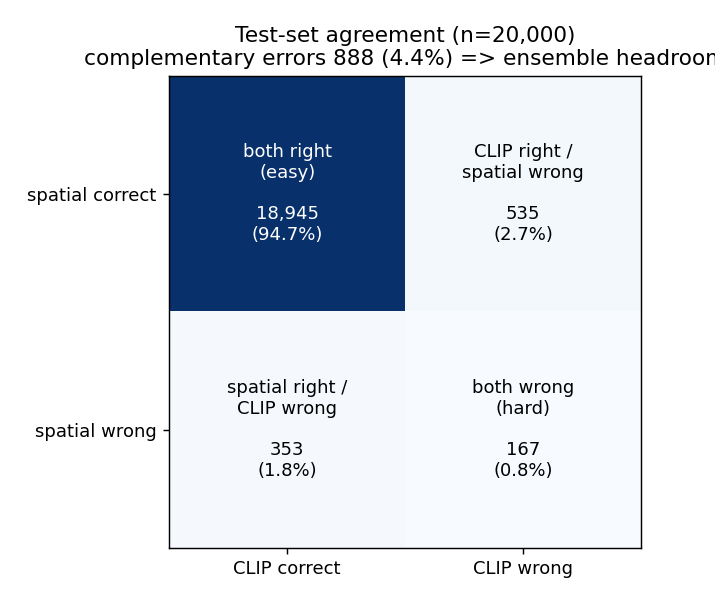

In [7]:
display(Image(str(FIG / '05_clip_vs_spatial_agreement.png')))

## 7. Calibration check

The final CLIP MLP probe is well-calibrated on the sealed test set —
the reliability curve sits essentially on the diagonal across the
[0, 1] range of predicted probabilities.

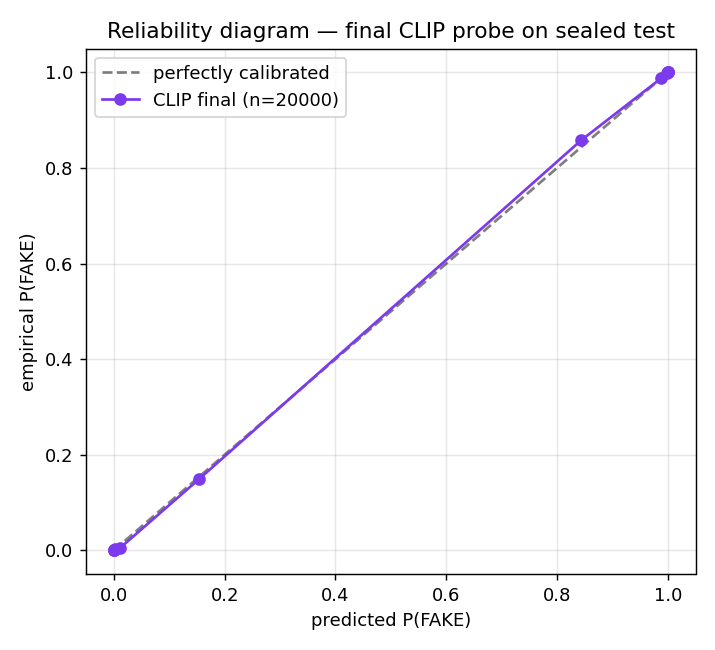

In [8]:
display(Image(str(FIG / '06_clip_calibration.png')))

## 8. Frequency-detector findings — interpretability sidebar

Although the frequency detector loses to spatial models on every detection
metric, it produces an interpretable spectral fingerprint of SD-1.4 that no
spatial model can give. These three figures are the headline interpretability
artifacts.

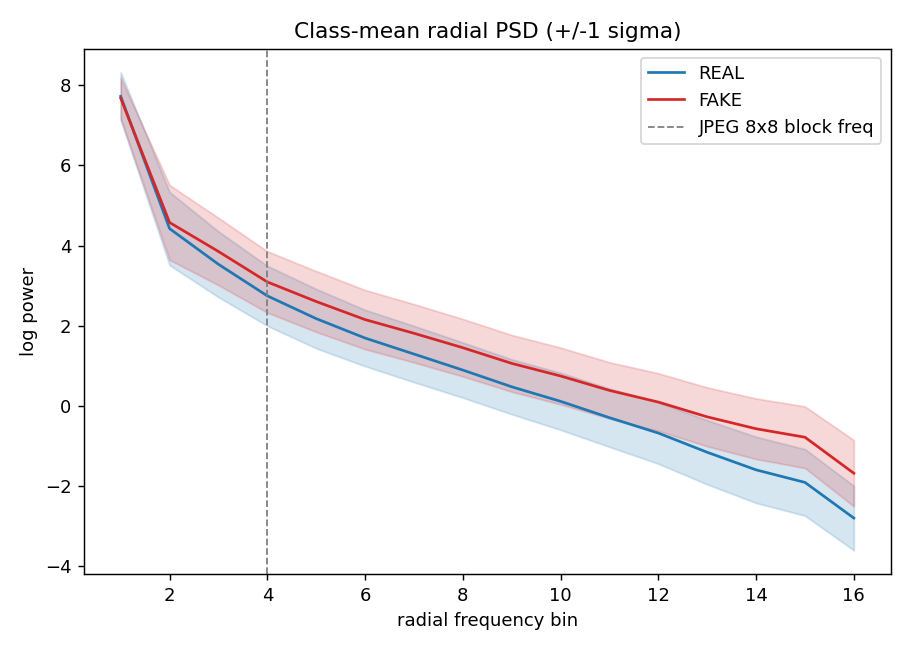

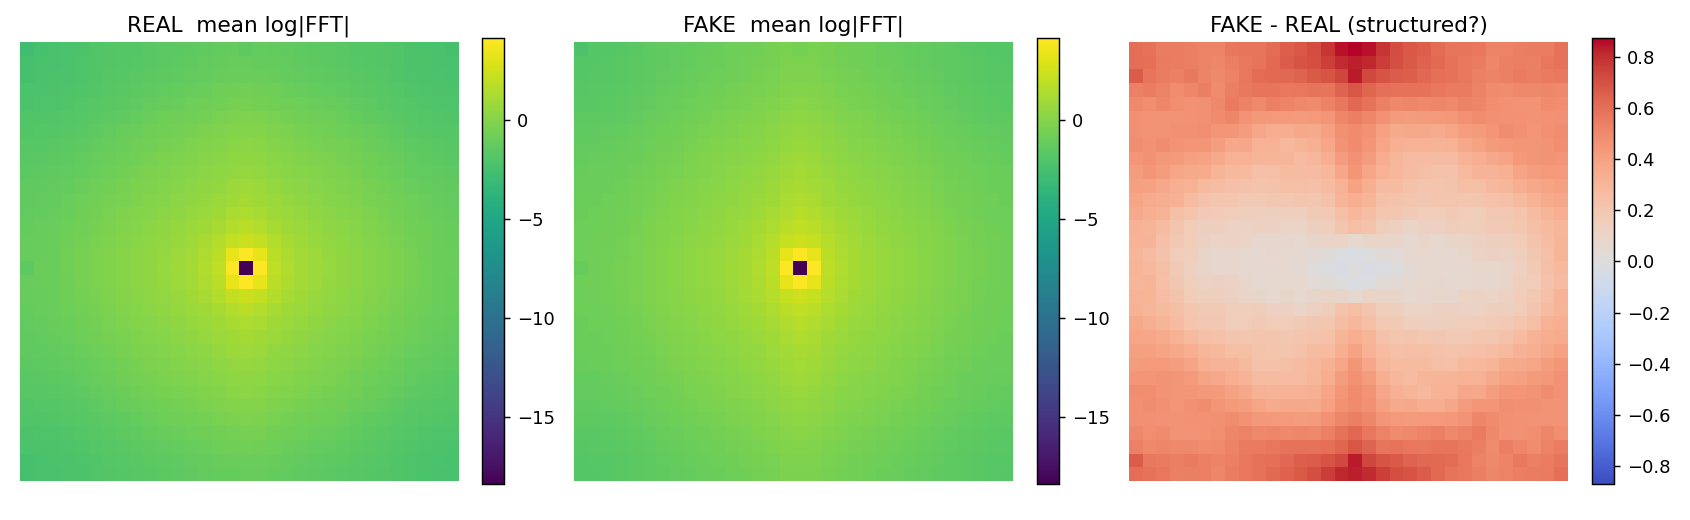

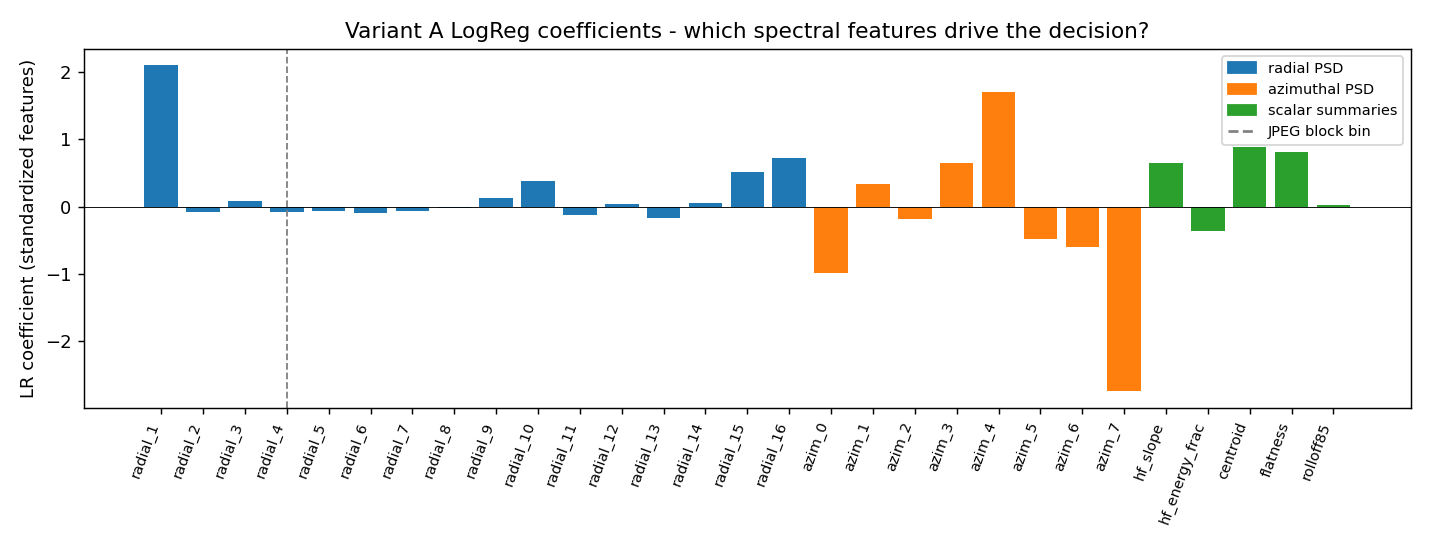

In [9]:
display(Image(str(FIG / '07_freq_radial_psd.png')))
display(Image(str(FIG / '08_freq_mean_spectra.png')))
display(Image(str(FIG / '09_freq_lr_coefficients.png')))

## 9. Recommended team headline for the report

> *We compared five models on CIFAKE through a shared evaluation harness.
> All four spatial models cleared ≥0.997 in-distribution test AUROC — the
> in-distribution problem is genuinely easy. The cross-generator OOD axis
> (against sd-turbo, content + JPEG-quantization matched) is where models
> separate: Alex's ViT-Small has the smallest drop (−2.6 pp), Yin's
> from-scratch CNN −5.5 pp, Nathan's ResNet-18 −6.4 pp, Leyi's CLIP
> probe −4.9 pp, and Leyi's frequency detector −12.8 pp. Surprisingly,
> Yin's from-scratch CNN OOD-drops less than Nathan's ImageNet-warm-
> started ResNet — pure CIFAKE training generalises slightly better
> than ImageNet transfer under cross-generator stress. The recommended
> team ensemble for cross-generator robustness is the triple
> Yin's CNN + Alex's ViT + Leyi's CLIP probe — together they reach
> 0.9670 OOD AUROC, beating the best pair (Alex + CLIP, 0.9657) by
> +0.13 pp through Yin's positive leave-one-out contribution. The
> frequency detector is included as an interpretability appendix: its
> LR coefficients over radial PSD bands produce a falsifiable physical
> claim about Stable Diffusion 1.4's spectral fingerprint that no
> spatial model can generate.*

For the deck, the three figures to lead with are
`01_clean_vs_ood.png`, `02_robustness_curves.png`, and `03_team_ensemble.png`.
Background material lives in `docs/`.